In [1]:
import sys
import os 

# os.environ["CONFIG_PATHS"] = "../configs/play_server_20.yaml"
# os.environ["CONFIG_OVERRIDES"] = 'game.moves_directory="../data/moves_20_regen_3"'
os.environ["CONFIG_PATHS"] = "../configs/training_unlooped/convolutional_policy_head.yaml"
os.environ["CONFIG_OVERRIDES"] = 'game.moves_directory="../data/moves_10_3",development.debug_mode=false'
sys.path.append("../src")

from display import Display
from neural_net import NeuralNet
import player_pov_helpers
from training.load_games import load_games
from state import State
from display import Display

from configuration import moves_data, config
import numpy as np
import torch

Loaded config:  {"development": {"debug_mode": false}, "game": {"board_size": 10, "num_moves": 6233, "num_pieces": 21, "num_piece_orientations": 91, "moves_directory": "../data/moves_10_3"}, "training": {"batch_size": 128, "policy_loss_weight": 0.158, "learning_rate": "overridden"}, "networks": {"default": {"main_body_channels": 96, "value_head_channels": 16, "value_head_flat_layer_width": 64, "policy_head_channels": 96, "residual_blocks": 16}}, "agents": []}
Loading file: center_placement_x
Loading file: piece_indices
Loading file: center_placement_y
Loading file: rotation_mapping
Loading file: new_occupieds
Loading file: moves_ruled_out_for_all
Loading file: piece_orientation_indices
Loading file: scores
Loading file: moves_ruled_out_for_player
Loading file: moves_enabled_for_player
Loading file: new_adjacents
Loading file: new_corners
Loading file: placement_x
Loading file: placement_y


In [2]:
model = NeuralNet(config()["networks"]["default"])
# model.load_state_dict(torch.load("/Users/shivamsarodia/Dev/blockus/data/notebook-models/0aa7e4f722ad45cc8964469a/epoch_1.pt", weights_only=True))
model.eval()

NeuralNet(
  (convolutional_block): Sequential(
    (0): Conv2d(5, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (residual_blocks): ModuleList(
    (0-15): 16 x ResidualBlock(
      (convolutional_block): Sequential(
        (0): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
  )
  (value_head): Sequential(
    (0): Conv2d(96, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Flatten(start_dim=1, end_dim=-1)

In [3]:
model_parameters = filter(lambda p: p.requires_grad, model.parameters())
print("Model size:", sum(p.numel() for p in model_parameters))

Model size: 2931007


In [4]:
input = np.zeros((1, 4, 10, 10), dtype=np.bool)
input[0, :, :, :] = moves_data()["new_occupieds"][2942]

values, policies = model(torch.from_numpy(input).to(torch.float32))

In [5]:
values = set()
for x, y, z in zip(
    moves_data()["piece_orientation_indices"],
    moves_data()["placement_x"],
    moves_data()["placement_y"],
):
    values.add((x, y, z))

len(values)

6233

KeyboardInterrupt: 

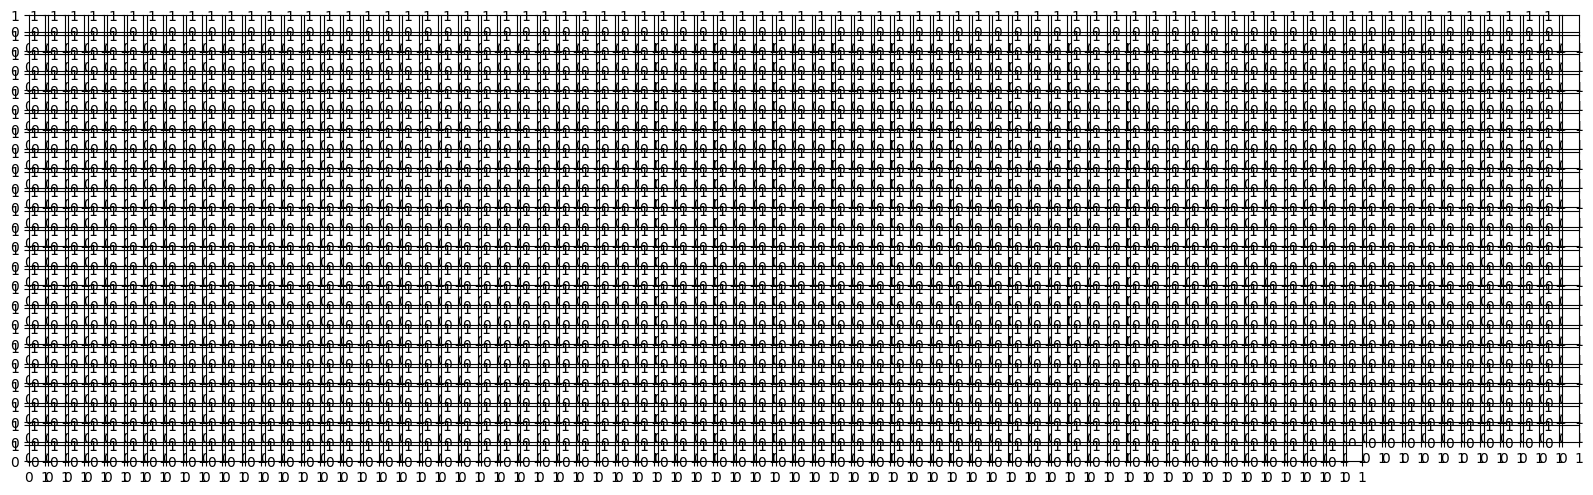

In [6]:
import matplotlib.pyplot as plt

# Convert policies tensor to numpy array and squeeze batch dimension
policy_grids = policies.detach().numpy().squeeze(0)

# Create a figure with subplots arranged in a grid
num_orientations = policy_grids.shape[0]
rows = int(np.ceil(np.sqrt(num_orientations)))
cols = int(np.ceil(num_orientations / rows))

fig, axes = plt.subplots(rows, cols, figsize=(20, 20))
axes = axes.flatten()

# Plot each orientation's grid
for i in range(num_orientations):
    # Create a diverging colormap centered at 0
    # Normalize the values to be between 0 and 1 for proper color mapping
    grid = policy_grids[i]
    grid = (grid - grid.min()) / (grid.max() - grid.min())
    
    im = axes[i].imshow(grid, cmap='RdYlGn')
    axes[i].set_title(f'Orientation {i}')
    axes[i].axis('off')

# Remove empty subplots
for i in range(num_orientations, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [ ]:
moves_data()["new_occupieds"][2942]

In [ ]:
np.argmax(policies.numpy(force=True)[0])

In [ ]:
state = State()
state.play_move(1020)
overlay_dots = np.zeros((10, 10))
overlay_dots[3, 5] = 1
print(moves_data()["piece_orientation_indices"][1020])
Display(
    state.occupancies, overlay_dots,
).show()

In [ ]:
import random
index = random.randint(0, 6233)
print(index)

state = State()
state.play_move(index)
overlay_dots = np.zeros((10, 10))
overlay_dots[
    moves_data()["placement_x"][index],    
    moves_data()["placement_y"][index],
] = 1
Display(
    state.occupancies, overlay_dots,
).show()

In [57]:
import torch
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import namedtuple

In [17]:
def load_games(game_file_paths):
    occupancies = []
    policies = []
    final_game_values = []
    average_rollout_values = []
    valid_moves_array = []
    game_ids = []

    for game_file in game_file_paths:
        with open(game_file, "rb") as f:
            npz = np.load(f)
            occupancies.append(npz["occupancies"])
            policies.append(npz["policies"])
            final_game_values.append(npz["final_game_values"])
            average_rollout_values.append(npz["average_rollout_values"])
            game_ids.append(npz["game_ids"])
            valid_moves_array.append(npz["valid_moves_array"])

    return (
        np.concatenate(occupancies),
        np.concatenate(policies),
        np.concatenate(final_game_values),
        np.concatenate(average_rollout_values),
        np.concatenate(valid_moves_array),
    )


boards, policies, final_game_values, average_rollout_values, valid_moves_array = load_games([
    "../data/2024-11-26_22-50-22-halebi/games/1732690842003_2.npz",
])

In [ ]:
np.any(policies[1][~valid_moves_array[1]])

In [ ]:
boards, policies, final_game_values, average_rollout_values = gamedata

In [39]:
# np.savez(
#     "/tmp/raw.npz",
#     occupancies=boards,
#     policies=policies,
#     final_game_values=final_game_values,
#     average_rollout_values=average_rollout_values,
# )
np.savez_compressed(
    "/tmp/raw_compressed.npz",
    game_ids=np.zeros(5),
    occupancies=boards,
    policies=policies,
    final_game_values=final_game_values,
    average_rollout_values=average_rollout_values,
)

In [ ]:
!ls -lh /tmp/raw*.npz

In [ ]:
13.2 / 81000

In [40]:
gamedata2 = load_games([
    "/tmp/raw_compressed.npz",
])
boards2, policies2, final_game_values2, average_rollout_values2 = gamedata2

In [ ]:
boards2.shape == boards.shape

In [ ]:
print((boards2 == boards).all())
print((policies2 == policies).all())
print((final_game_values2 == final_game_values).all())
print((average_rollout_values2 == average_rollout_values).all())


In [ ]:
for board in occupancies:
    if np.sum(board[0]) == 5:
        print(board[0])

In [109]:
Event = namedtuple('Event', [
    'timestamp',
    'name',
    'params',
]) 

def load_events(log_path):
    events = []
    with open(log_path) as f:
        logs = f.readlines()
        for line in logs:
            # Skip lines that are not events.
            if not line.startswith("event | "):
                continue

            _, timestamp, event, params = line.strip().split(" | ")
            events.append((float(timestamp), event, json.loads(params)))

    # Sort events by timestamp.
    events.sort(key=lambda x: x[0])

    # Adjust timestamps to start at 0.
    start_time = events[0][0]
    print(f"Start time: {start_time}")

    return [
        Event(
            timestamp=timestamp - start_time,
            name=event,
            params=params,
        )
        for timestamp, event, params in events
    ]

In [15]:
MOVES = moves_data()

In [13]:
# first move, by player 0: 2942
# second move, by player 1 recommended by the policy network: 2914 (in universal)

gamefile = np.load("../data/2024-11-29_23-05-39-erpetologist/games/1732950430040_4.npz")
boards = gamefile["boards"]
policies = gamefile["policies"]
values = gamefile["values"]
unused_pieces = gamefile["unused_pieces"]

In [ ]:
i = 1

used_pieces = ~unused_pieces[i][3]

move_index = np.flatnonzero(MOVES["piece_indices"] == np.flatnonzero(used_pieces)[0])[0]

Display(
    boards[i],
    MOVES["new_occupieds"][move_index],
).show()

In [ ]:
np.argmax(policies[0])

In [ ]:
model = NeuralNet(config()["networks"]["default"])
model.load_state_dict(torch.load("../data/2024-11-20_17-29-54-solitude/models/2024-11-20_08-24-43_975055.pt", weights_only=True))

In [89]:
model.eval()
values, policies = model(torch.Tensor(occupancies))

In [ ]:
torch.softmax(values[0], dim=0)

In [ ]:
torch.argmax(policies[0])

In [ ]:
events = 

In [115]:
reports = [event for event in events if event.name == "mcts_report"]

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(range(len(reports[0].params["children_visit_counts"])), reports[0].params["children_visit_counts"])
plt.title("Children Visit Counts")
plt.xlabel("Index")
plt.ylabel("Visit Count")
plt.xticks(range(0, len(reports[0].params["children_visit_counts"]), 5))
plt.grid(True, axis='y')
plt.show()


In [ ]:
gamedata_path = "/Users/shivamsarodia/Dev/blockus/data/2024-11-20_23-29-01-chickpea/games"
gamedata_paths = [
    os.path.join(gamedata_path, filename)
    for filename in os.listdir(gamedata_path)
    if filename.endswith(".npz")
]
len(gamedata_paths)

In [17]:
games = load_games(gamedata_paths)

In [ ]:
games[2].size

In [31]:
# First, check what game data files are available.
gamedata_paths = [
    os.path.join(gamedata_path, filename)
    for filename in os.listdir(gamedata_path)
    if filename.endswith(".npz")
]

paths_with_sample_counts = [
    (path, int(path.split("_")[-1].split(".")[0]))
    for path in gamedata_paths
]

total_sample_count = sum(count for path, count in paths_with_sample_counts)

In [ ]:
total_sample_count

In [ ]:
total_samples_available

In [ ]:
import random

data = [0]
samples = []

window_size = 50000

for _ in range(500):
    new_sample_count = random.randint(1, 2000)

    # New set of samples comes in.
    # Add these to our running data.
    for _ in range(new_sample_count):
        data.append(data[-1] + 1)
    
    # Remove data that's outside the window.
    data = data[-window_size:]

    # We sample data points.
    if len(data) >= window_size / 2:
        samples += random.choices(data, k=new_sample_count)

plt.hist(samples, bins=200)

In [13]:
from collections import Counter

data = Counter(samples)

In [ ]:
data.most_common(50)

In [ ]:
import numpy as np 

unused_pieces = np.zeros((4, 7, 7))
unused_pieces[0][0][0] = 5

player_pov_helpers.unused_pieces_to_player_pov(unused_pieces, 1)

In [ ]:
model_sample_counts_to_select = [
    200000,
    400000,
    800000,
    1000000,
    1100000,
    1200000,
    1300000,
    1400000,
    1500000,
    1600000,
    1700000,
    1800000,
    1900000,
    2000000,
    2100000,
    2190000,
]
current_sample_count_index = 0

import glob

model_files = glob.glob('/Users/shivamsarodia/Dev/blockus/data/2024-11-23_00-37-50-doublehandedness/models/*.pt')
model_files.sort()

selected_model_files = {}

for model_file in model_files:
    model_file_sample_count = int(model_file.split("/")[-1].split(".")[0])
    if model_file_sample_count > model_sample_counts_to_select[current_sample_count_index]:
        selected_model_files[model_file_sample_count] = model_file
        current_sample_count_index += 1

print("Num model files:", len(selected_model_files))

print("individual_networks:")
for sample_count, model_file in selected_model_files.items():
    print(f"  \"{sample_count}\":")
    print(f"    model_path: \"{model_file}\"")

print("individual_agents:")
for sample_count, model_file in selected_model_files.items():
    print(f"  - name: \"{sample_count}\"")
    print(f"    network: \"{sample_count}\"")

In [ ]:
model_files[0]